In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import linalg as la
from matplotlib.collections import LineCollection
from matplotlib.colors import BoundaryNorm, ListedColormap
matplotlib.rcParams.update({'font.size': 12, 'text.usetex': True, 'font.family': 'serif', 'font.serif': ['Computer Modern']})

In [9]:
import numpy as np
import scipy.linalg as la
from matplotlib import pyplot as plt
from matplotlib import cm
import time
import math as m


def list_repeated_energies(energies, threshold=1e-8, shift=0):
    """
    This code takes a list of energies (has to be in ascending order or it won't work) and returns
    the list of each index of degenerate states!
    :param shift:
    :param energies: real list of energies
    :param threshold: threshold difference at which two energies are considered equal
    :return: a list of tuples of every repeated set of eigenvalues
    """
    if (all(energies[i] <= energies[i + 1] for i in range(len(energies) - 1))) is False:
        raise Exception(
            'You need to pass a list of energies in ascending order')

    energies_last = -np.inf
    degen_list = []
    temp_degen_list = [0]
    degen_last = False

    for i, energy_current in enumerate(energies):

        if abs(energy_current - energies_last) <= threshold:
            degen_current = True
        else:
            degen_current = False

        if degen_current is True and i != energies.__len__() - 1:
            temp_degen_list.append(i + shift)
        elif degen_current is True and i == energies.__len__() - 1:
            temp_degen_list.append(i + shift)
            degen_list.append(tuple(temp_degen_list))
        elif degen_current is False and degen_last is True:
            degen_list.append(tuple(temp_degen_list))
            temp_degen_list = [i + shift]
        else:
            temp_degen_list = [i + shift]

        degen_last = degen_current
        energies_last = energy_current

    return degen_list


def pick_right_states_extended(H: np.ndarray, perturbations: list, threshold=1e-8, return_list=False):
    """
    This code takes the eigenstates of H. Then it looks at all the degenerate
    states of H and uses each matrix in the list 'perturbations' to lift
    the degeneracy.
    :param H: Initial Hamiltonian to diagonalise
    :param perturbations: A list of perturbing Hamiltonians in the order that you want them applied to H
    :param threshold: Threshold at which two energies are considered degenerate
    :param return_list: do you want to be given a list of the remaining degeneracies?!
    :return: energies, states, and a list of remaining degeneracies!
    """

    num_perturbations = perturbations.__len__()

    # solve the states of the hamiltonian
    energies, states = la.eigh(H)
    degen_list = list_repeated_energies(energies, threshold=threshold)

    list_out = [degen_list]

    if degen_list == []:
        # the states are perfect - there is already no degeneracy :)
        if return_list == True:
            return energies, states, list_out
        else:
            return energies, states

    for i, pert in enumerate(perturbations):
        # for each successive perturbation this keeps track of the degeneracy that remains!
        remaining_degeneracy = []

        for j, deg_set in enumerate(degen_list):
            # for each degenerate set of states

            subspace = states[:, deg_set]
            hdot_on_subspace = subspace.conj().T @ pert @ subspace
            hdot_on_subspace = 0.5 * \
                (hdot_on_subspace + hdot_on_subspace.conj().T)

            # find the eigenvectors the perturbation on the degenerate subspace
            e, v = la.eigh(hdot_on_subspace)

            subdegen_shifted = list_repeated_energies(e, shift=deg_set[0])
            subdegen = list_repeated_energies(e)

            if subdegen_shifted == [deg_set]:
                # all the states are still degenerate so don't do anything
                remaining_degeneracy.extend(subdegen_shifted)
            else:
                # now if there is some degeneracy that can be lifted
                states[:, deg_set] = subspace @ v
                remaining_degeneracy.extend(subdegen_shifted)

        degen_list = remaining_degeneracy

        list_out.append(remaining_degeneracy)

    if return_list == True:
        return energies, states, list_out
    else:
        return energies, states


In [10]:
def strip_ham(u, ky, bcs, L):
    sz = np.array([[1, 0], [0, -1]])
    sx = np.array([[0, 1], [1, 0]])
    sy = np.array([[0, -1j], [1j, 0]])

    A = (u+np.cos(ky) )*sz + np.sin(ky)*sy
    B = 0.5*(sz + 1j*sx)

    H = np.zeros((2*L, 2*L), dtype=complex)
    i = np.eye(L)

    # H = np.kron(i,A) 

    if bcs == 'pbc':
        H = np.kron(i,A) + np.kron(np.roll(i,1, axis=0),B) + np.kron(np.roll(i,-1, axis=0),B.conj())
    elif bcs == 'obc':


        H = np.kron(i,A) + np.kron(np.roll(i,1, axis=0),B) + np.kron(np.roll(i,-1, axis=0),B.conj())
        H[0:2, 2*L-2:2*L] = 0
        H[2*L-2:2*L, 0:2] = 0

        
    return H



def inv_matrix(L):
    i = np.eye(L)
    return np.kron(i, np.array([
        [1,0], 
        [0, -1]
]))




0.0


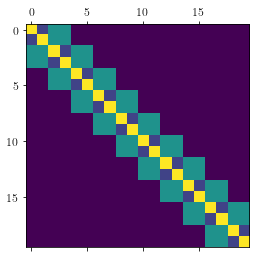

In [11]:
H = strip_ham(0, 0.2, 'obc', 10)
plt.matshow(np.abs(H))

print(np.sum(np.abs(H - H.conj().T)))

In [12]:
L = 50





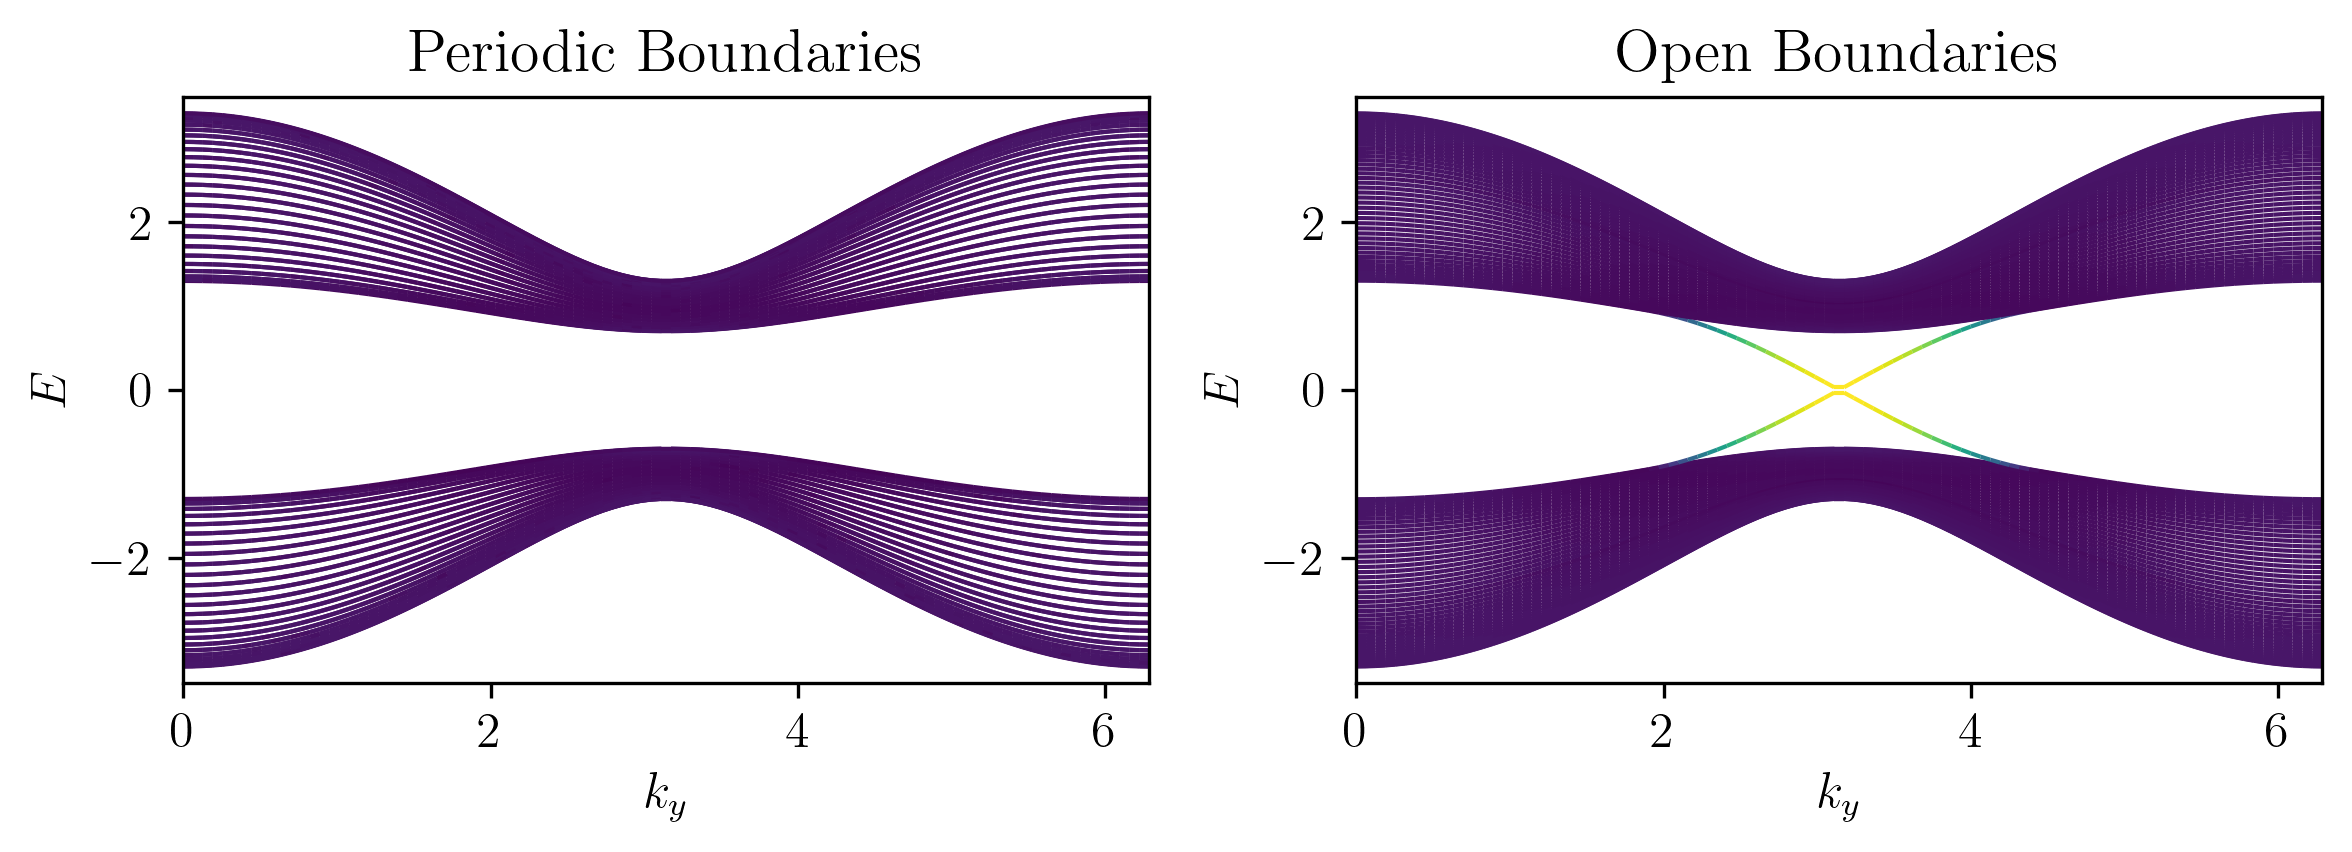

In [13]:

fig, axes = plt.subplots(1,2, figsize=(8,3), dpi = 300)

for ax, bcs in zip(axes, ['pbc', 'obc']):
    e_vals = []
    ipr_vals = []
    k_vals = np.linspace(0, 2*np.pi, 100)

    for k in k_vals:
        H = strip_ham(1.3, k, bcs, L)

        # e,v  = pick_right_states_extended(H, [inv_matrix(L)] )
        e,v  = la.eigh(H)
        e_vals.append(e)

        ipr = np.sum(np.abs(v**4), axis=0)
        ipr_vals.append(ipr)


    e_vals = np.array(e_vals)
    ipr_vals = np.array(ipr_vals)


    x = k_vals
    norm = plt.Normalize(0.005583597607119586, 0.41717679975789673)



    for n in range(len(e_vals[0,:])):
        y = e_vals.T[n]
        ipr = ipr_vals.T[n]

        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap='viridis', norm=norm)
        lc.set_array(ipr)
        lc.set_linewidth(1)
        line = ax.add_collection(lc)

    ax.set_xlim(0, 2*np.pi)
    ax.set_ylim(-3.5,3.5)

    title = 'Periodic Boundaries' if bcs == 'pbc' else 'Open Boundaries'
    ax.set_title(title)
    ax.set_xlabel(r'$k_y$')
    ax.set_ylabel(r'$E$')


# arrange tight
plt.tight_layout()

plt.savefig('strip_energy.pdf')
plt.show()